<a href="https://colab.research.google.com/github/classicclown/Loffee-Labs/blob/EDA/Coffee_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import io
import difflib
import re
import matplotlib.pyplot as plt
import seaborn as sns



##Import datasets

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Data Analytics projects /Loffee labs/LOFFEE LABS BEAN BASE 9.23.2024.csv', encoding='latin1')
roasters_df = pd.read_csv('/content/drive/MyDrive/Data Analytics projects /Loffee labs/Roasters info.csv')

In [3]:
df.head()

,Date Added,Bean ID #,Roaster,Roast Name,General Tags,Roast Degree,Origins,Regions,Producer Info,Elevation (MASL),...,Price/Bag,Gram/Bag,Retail Price/Cup (20g),Bulk Price/Cup (20g),Roaster Region,Roaster Country,Tasting Notes,General Tasting Notes,Link,Available?
0,9/23/2024,6979,49th Parallel Coffee Roasters,Honduras La Maravilla Sof,"Single Origin, Single Varietal, Traceable","Filter, Light",Honduras,Santa Barbara,Juan Evangelista,"1,500.00",...,$19.22,301,$1.28,$1.15,NaN,Canada,"Butterscotch, Granny Smith, Pink Lemonade","Caramel, Citrus Fruit, Sweet, Creamy, Common F...",https://49thcoffee.com/collections/filter/prod...,YES
1,9/23/2024,6978,Tiny Arms Coffee,Ethiopia Goraa Honey,"Single Origin, Traceable",-,Ethiopia,"Oromia, Guji","Ture Waji, Sookoo Coffee (Dambi Uddo Agro Indu...","2,173.00",...,$22.50,283,$1.59,$1.15,NaN,USA,"Georgia Peach, Black Tea, Sugarcane","Stone Fruit, Sweet, Tea Like",https://tinyarms.co/products/ethiopia-goraa-honey,YES
2,9/23/2024,6977,Klatch Coffee,Organic Guatemala Joyabaj Chauquenem Natural F...,"Single Origin, Traceable",Medium,Guatemala,-,La FederaciÃ³n Comercializadora de CafÃ© Espec...,-,...,$18.95,310,$1.22,$0.84,NaN,USA,Blueberry - Blackberry - Granola,"Berries, Cereal, Dried Fruit",https://www.klatchcoffee.com/collections/singl...,YES
3,9/23/2024,6976,Saint Frank Coffee,Bolivia Don Pancho,"Single Origin, Traceable",-,Bolivia,"Siete Estrellas, Caranavi",Francisco Hilari,1550 - 1600,...,$20.00,283,$1.41,$1.14,NaN,USA,Dynamic And Sweet Like Salted Caramel With Sub...,"Caramel, Chocolate, Complex, Dried Fruit, Ston...",https://www.saintfrankcoffee.com/products/boli...,CHECK LINK
4,9/23/2024,6975,House of Funk Brewing Co.,The Diamond Sea Ethiopia Filter,"Single Origin, Single Varietal, Traceable",Filter,Ethiopia,"Wanja Kersa Kebele, Jimma",Multiple smallholder farmers,"2,000.00",...,$22.50,250,$1.80,$1.23,NaN,USA,"Poached Pear, Maple Syrup, Spice Cookie","Common Fruit, Spiced, Sweet",https://www.houseoffunkbrewing.com/en-us/colle...,YES


In [4]:
roasters_df.head()

,Name,Region,Country,City
0,19 Grams Coffee,EMEA,Germany,Berlin
1,49th Parallel Coffee Roasters,NaN,Canada,Vancouver
2,4LW – Four Letter Word Coffee,NaN,USA,"Chicago, Illinois"
3,About Us Coffee,APAC,Japan,Kyoto
4,Acid Coffee,APAC,Japan,Tokyo


In [5]:
df.drop(columns=['Link','Available?','Bean ID #'], inplace=True)

In [6]:
roasters_df.isna().sum()

,0
Name,0
Region,101
Country,0
City,0


In [7]:
roasters_df.drop(columns=['Region'], inplace=True)

In [30]:
merged_df.head()

,Date Added,Roaster,Country,City,Roast Name,Origins,Process,Processing Tags,Regions,Roast Degree,...,Elevation (MASL),Tasting Notes,General Tasting Notes,Producer Info,General Tags,Price/Bag,Gram/Bag,Retail Price/Cup (20g),Bulk Price/Cup (20g),Is_Blend
0,2024-09-23,49th Parallel Coffee Roasters,Canada,Vancouver,Honduras La Maravilla Sof,Honduras,Washed,Washed,Santa Barbara,"Filter, Light",...,1500.0,"Butterscotch, Granny Smith, Pink Lemonade","Caramel, Citrus Fruit, Sweet, Creamy, Common F...",Juan Evangelista,"Single Origin, Single Varietal, Traceable",19.22,301,1.28,1.15,False
1,2024-09-23,Tiny Arms Coffee,USA,"Lowell, Massachusetts",Ethiopia Goraa Honey,Ethiopia,Honey,"Honey, Dried on Raised Beds","Oromia, Guji",-,...,2173.0,"Georgia Peach, Black Tea, Sugarcane","Stone Fruit, Sweet, Tea Like","Ture Waji, Sookoo Coffee (Dambi Uddo Agro Indu...","Single Origin, Traceable",22.50,283,1.59,1.15,False
2,2024-09-23,Klatch Coffee,USA,"Rancho Cucamonga, California",Organic Guatemala Joyabaj Chauquenem Natural F...,Guatemala,Natural,Natural,-,Medium,...,1500.0,Blueberry - Blackberry - Granola,"Berries, Cereal, Dried Fruit",La FederaciÃ³n Comercializadora de CafÃ© Espec...,"Single Origin, Traceable",18.95,310,1.22,0.84,False
3,2024-09-23,Saint Frank Coffee,USA,"San Francisco, California",Bolivia Don Pancho,Bolivia,Fully Washed,Washed,"Siete Estrellas, Caranavi",-,...,1575.0,Dynamic And Sweet Like Salted Caramel With Sub...,"Caramel, Chocolate, Complex, Dried Fruit, Ston...",Francisco Hilari,"Single Origin, Traceable",20.00,283,1.41,1.14,False
4,2024-09-23,House of Funk Brewing Co.,USA,Vancouver,The Diamond Sea Ethiopia Filter,Ethiopia,Washed,Washed,"Wanja Kersa Kebele, Jimma",Filter,...,2000.0,"Poached Pear, Maple Syrup, Spice Cookie","Common Fruit, Spiced, Sweet",Multiple smallholder farmers,"Single Origin, Single Varietal, Traceable",22.50,250,1.80,1.23,False


##Data preprocessing and cleaning

In [8]:
def clean_name(name):
    name = re.sub(r'\b(coffee|roasters|roaster|roastery)\b', '', name, flags=re.IGNORECASE)
    return name.strip().lower()

def get_best_match(name, choices):
    match = difflib.get_close_matches(name, choices, n=1, cutoff=0.85)
    return match[0] if match else None

#Clean the names first
roasters_df['Cleaned Name'] = roasters_df['Name'].apply(clean_name)
df['Cleaned Name'] = df['Roaster'].apply(clean_name)

#Apply matching
roasters_df['Matched Name'] = roasters_df['Cleaned Name'].apply(lambda x: get_best_match(x, df['Cleaned Name']))
merged_df = pd.merge(df, roasters_df, left_on='Cleaned Name', right_on='Cleaned Name', how='inner')
merged_df=merged_df[['Date Added','Roaster','Country','City','Roast Name','Origins','Process','Processing Tags','Regions','Roast Degree','Varietals','Elevation (MASL)','Tasting Notes','General Tasting Notes','Producer Info','General Tags','Price/Bag','Gram/Bag','Retail Price/Cup (20g)','Bulk Price/Cup (20g)']]

merged_df.head()


,Date Added,Roaster,Country,City,Roast Name,Origins,Process,Processing Tags,Regions,Roast Degree,Varietals,Elevation (MASL),Tasting Notes,General Tasting Notes,Producer Info,General Tags,Price/Bag,Gram/Bag,Retail Price/Cup (20g),Bulk Price/Cup (20g)
0,9/23/2024,49th Parallel Coffee Roasters,Canada,Vancouver,Honduras La Maravilla Sof,Honduras,Washed,Washed,Santa Barbara,"Filter, Light",Parainema,"1,500.00","Butterscotch, Granny Smith, Pink Lemonade","Caramel, Citrus Fruit, Sweet, Creamy, Common F...",Juan Evangelista,"Single Origin, Single Varietal, Traceable",$19.22,301,$1.28,$1.15
1,9/23/2024,Tiny Arms Coffee,USA,"Lowell, Massachusetts",Ethiopia Goraa Honey,Ethiopia,Honey,"Honey, Dried on Raised Beds","Oromia, Guji",-,74110 & 74112,"2,173.00","Georgia Peach, Black Tea, Sugarcane","Stone Fruit, Sweet, Tea Like","Ture Waji, Sookoo Coffee (Dambi Uddo Agro Indu...","Single Origin, Traceable",$22.50,283,$1.59,$1.15
2,9/23/2024,Klatch Coffee,USA,"Rancho Cucamonga, California",Organic Guatemala Joyabaj Chauquenem Natural F...,Guatemala,Natural,Natural,-,Medium,"Bourbon, CatuaÃ­, Caturra",-,Blueberry - Blackberry - Granola,"Berries, Cereal, Dried Fruit",La FederaciÃ³n Comercializadora de CafÃ© Espec...,"Single Origin, Traceable",$18.95,310,$1.22,$0.84
3,9/23/2024,Saint Frank Coffee,USA,"San Francisco, California",Bolivia Don Pancho,Bolivia,Fully Washed,Washed,"Siete Estrellas, Caranavi",-,"Typica, Caturra, And Catuai",1550 - 1600,Dynamic And Sweet Like Salted Caramel With Sub...,"Caramel, Chocolate, Complex, Dried Fruit, Ston...",Francisco Hilari,"Single Origin, Traceable",$20.00,283,$1.41,$1.14
4,9/23/2024,House of Funk Brewing Co.,USA,Vancouver,The Diamond Sea Ethiopia Filter,Ethiopia,Washed,Washed,"Wanja Kersa Kebele, Jimma",Filter,Jarc 74112,"2,000.00","Poached Pear, Maple Syrup, Spice Cookie","Common Fruit, Spiced, Sweet",Multiple smallholder farmers,"Single Origin, Single Varietal, Traceable",$22.50,250,$1.80,$1.23


In [9]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6643 entries, 0 to 6642
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Date Added              6643 non-null   object
 1   Roaster                 6643 non-null   object
 2   Country                 6643 non-null   object
 3   City                    6643 non-null   object
 4   Roast Name              6643 non-null   object
 5   Origins                 6643 non-null   object
 6   Process                 6643 non-null   object
 7   Processing Tags         6629 non-null   object
 8   Regions                 6643 non-null   object
 9   Roast Degree            6643 non-null   object
 10  Varietals               6641 non-null   object
 11  Elevation (MASL)        6642 non-null   object
 12  Tasting Notes           6642 non-null   object
 13  General Tasting Notes   6629 non-null   object
 14  Producer Info           6643 non-null   object
 15  Gene

Convert types to correct formats

In [10]:
merged_df['Date Added']=pd.to_datetime(merged_df['Date Added'])
merged_df['Price/Bag']=pd.to_numeric(merged_df['Price/Bag'].str.replace('$',''),errors='coerce')
merged_df['Gram/Bag']=pd.to_numeric(merged_df['Gram/Bag'].str.replace(',',''))
merged_df['Retail Price/Cup (20g)']=pd.to_numeric(merged_df['Retail Price/Cup (20g)'].str.replace('$',''))
merged_df['Bulk Price/Cup (20g)']=pd.to_numeric(merged_df['Bulk Price/Cup (20g)'].str.replace('$',''))

In [11]:
merged_df.isna().sum()

,0
Date Added,0
Roaster,0
Country,0
City,0
Roast Name,0
Origins,0
Process,0
Processing Tags,14
Regions,0
Roast Degree,0


MASL needs to be a numeric in order to work with it later on. There are a few problems:
- MASL are listed as ranges (ie 1600-1800)
- Some cells are not numbers
- Some cells have special charatcers due to encoding issues

We have to deal with these in order to get a numeric figure for each row.

In [12]:
def filter_MASL(altitude):
  if isinstance(altitude ,str):
      altitude = re.sub(r'[â]', '-', altitude)
      altitude = altitude.replace(',', '').strip()

      if altitude == '-':
          altitude = 0
      else:
        try:
            altitude = float(altitude.replace(',',''))
        except:
            if re.search(r'^\d+\s*-\s*\d+$', altitude):
                altitude=altitude.split('-')
                altitude1,altitude2=float(altitude[0].replace(',','')),float(altitude[1].replace(',',''))
                altitude=(altitude1+altitude2)/2
            else:
                altitude=0
  return altitude

merged_df['Elevation (MASL)']=merged_df['Elevation (MASL)'].apply(filter_MASL)
merged_df['Elevation (MASL)']=pd.to_numeric(merged_df['Elevation (MASL)'])

Next problem is we have over 1000 MASL of 0. I think that many of the coffee's origins are listed without MASL or the origin is hidden in the roast name so we can then deduce the MASL.


- Scenario 1: MASL is missing but the Origin field has the country
- Scenario 2: MASL is missing and the origin field doesn't have the country but the roast name includes the country
- Scenario 3: MASL is missing but the coffee is a blend of origins so MASL can be 0

In [13]:
average_masl = {
    'Bolivia': 1200,
    'Brazil': 1000,
    'Burundi': 1700,
    'China': 1200,
    'Colombia': 1500,
    'Costa Rica': 1500,
    'Democratic Republic of the Congo': 1400,
    'Ecuador': 1400,
    'El Salvador': 1400,
    'Ethiopia': 1800,
    'Guatemala': 1500,
    'Hawaii': 700,
    'Honduras': 1350,
    'India': 1100,
    'Indonesia': 1200,
    'Jamaica': 1000,
    'Kenya': 1700,
    'Malawi': 1300,
    'Mexico': 1350,
    'Myanmar': 1200,
    'Nicaragua': 1250,
    'Rwanda': 1700,
    'Panama': 1500,
    'Papua New Guinea': 1400,
    'Peru': 1500,
    'Philippines': 1200,
    'Taiwan': 1100,
    'Tanzania': 1600,
    'Thailand': 1100,
    'Timor Leste': 1200,
    'Uganda': 1500,
    'Vietnam': 800,
    'Yemen': 1500
}


#Adding MASL to rows without an origin but with the country in the roast name
for index, row in merged_df['Roast Name'].items():
    for country, masl in average_masl.items():
      if merged_df['Elevation (MASL)'][index]==0.0: #If MASL is 0
        if country in row: #And if the country is in the Roast Name
              merged_df.at[index, 'Elevation (MASL)'] = masl

#Let's add a MASL to any rows that have a single origin with no MASL
for index, row in merged_df['Origins'].items():
  merged_df.at[index,'Is_Blend']=True          #Add an extra feature to the data to determine if a coffee is a blend or single origin
  if merged_df.at[index, 'Elevation (MASL)'] == 0.0 or pd.isna(merged_df.at[index, 'Elevation (MASL)']): #If the MASL is 0
    if isinstance(row,str): #And the Origin cell is actually a string (Check to avoid errors)
      origin=re.split('/ |, ', row)
      if len(origin)==1: #if there is a single origin
          for country, masl in average_masl.items():
            if country in origin: #If the country from our dictionary is one of the Origins
                merged_df.at[index, 'Elevation (MASL)'] = masl #Then fill the MASL with the average for that country
                merged_df.at[index,'Is_Blend']=False
      elif len(origin)>1 and origin[0]==origin[1]: #If there are two origins but the origins are the same, ie Ethiopia, Ethiopia
        merged_df.at[index, 'Elevation (MASL)'] = masl
        merged_df.at[index,'Is_Blend']=False
  else:
    merged_df.at[index,'Is_Blend']=False


In [14]:
merged_df.isna().sum()

,0
Date Added,0
Roaster,0
Country,0
City,0
Roast Name,0
Origins,0
Process,0
Processing Tags,14
Regions,0
Roast Degree,0


In [15]:
merged_df['Price/Bag'].fillna(merged_df['Price/Bag'].mean(), inplace=True)


<ipython-input-15-b2b1fc82f2b4>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df['Price/Bag'].fillna(merged_df['Price/Bag'].mean(), inplace=True)


In [16]:
# Check for duplicates based on all columns
duplicates = merged_df[merged_df.duplicated(keep=False)]

if not duplicates.empty:
    print("Duplicate rows found:")
    print(duplicates)
else:
    print("No duplicate rows found.")

merged_df.drop_duplicates(inplace=True)

Duplicate rows found:
   Date Added          Roaster         Country    City Roast Name  \
92 2024-09-20  Workshop Coffee  United Kingdom  London     Legacy   
93 2024-09-20  Workshop Coffee  United Kingdom  London    Article   
95 2024-09-20  Workshop Coffee  United Kingdom  London     Legacy   
96 2024-09-20  Workshop Coffee  United Kingdom  London    Article   

           Origins Process Processing Tags                  Regions  \
92  Peru, Ethiopia  Washed          Washed       Colca, Yirgacheffe   
93    Brazil, Peru       -               -  Minas Gerais, Cajamarca   
95  Peru, Ethiopia  Washed          Washed       Colca, Yirgacheffe   
96    Brazil, Peru       -               -  Minas Gerais, Cajamarca   

   Roast Degree  ... Elevation (MASL)                  Tasting Notes  \
92         Omni  ...              0.0    Baking Spice, Toffee, Jammy   
93         Omni  ...              0.0  Dark Chocolate, Maple, Raisin   
95         Omni  ...              0.0    Baking Spice, Toffe

#EDA

Let's look at some descriptive stats, who are the largest producers and what do their elevations look like. Then we can look at roasters - how many are there and where are they from. Last, but not least, we can look at the coffee. Where is it grown, what elevations and what are the most popular processing methods. Are some varieties more popular? What about roast types? Which coffees are more likely to be used in a blend vs single origin? Lastly we can look at the tasting notes. Are there similarities between roasters from different countries/cities? What about similarities between coffees from different roasters but same origin.

In [17]:
merged_df.describe()

,Date Added,Elevation (MASL),Price/Bag,Gram/Bag,Retail Price/Cup (20g),Bulk Price/Cup (20g)
count,6641,6641.000000,6641.000000,6641.000000,6641.000000,6641.000000
mean,2024-05-30 11:11:32.245143808,1586.455052,24.574096,238.974703,2.819215,2.552384
min,2023-11-20 00:00:00,0.000000,2.920000,12.000000,0.530000,0.330000
25%,2024-04-02 00:00:00,1500.000000,17.100000,200.000000,1.330000,1.120000
50%,2024-05-31 00:00:00,1700.000000,21.350000,250.000000,1.650000,1.440000
75%,2024-08-08 00:00:00,1900.000000,26.000000,299.000000,2.480000,2.230000
max,2024-09-23 00:00:00,3000.000000,299.410000,1000.000000,256.530000,256.530000
std,NaN,512.617979,15.801446,96.785542,5.014139,4.844083


Average elevation - 1600± which is fairly high
Average price/bag - $24usd for 240 grams which makes sense since most of the coffees are single origin.
Average grams/bnag - American roasters have typically sold in 340 grams bags while the norm in other countries is 250 grams. Roasters are slowly trending towards 250grams I think.
Price/cup - There must be some incredibly rare coffees in the data at $256 for a cup. Same with price/bag at $300.


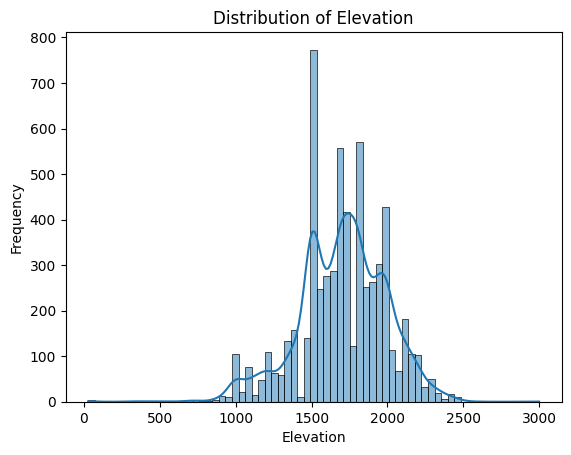

In [29]:
not_blend = merged_df[merged_df['Is_Blend']==False] #Removes all the coffees with a MASL of 0
sns.histplot(not_blend['Elevation (MASL)'], kde=True)
plt.title('Distribution of Elevation')
plt.xlabel('Elevation')
plt.ylabel('Frequency')
plt.show()

The distribution is somewhat symmetrical and resembles a normal distribution with a peak around 1500 although there are secondary peaks around 1800. The data looks slightly skewed towards the higher elevations. Could correspond to bulk of coffees being produced by a country whos Elevation is concentrated around 15-1800 MASL.

<ipython-input-18-843c4b598c24>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=origin_order, y=top_10_origins.values, palette='viridis')
<ipython-input-18-843c4b598c24>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Origins', y='Elevation (MASL)', data=top_10_df, palette='viridis', order=origin_order)  # Use the same order


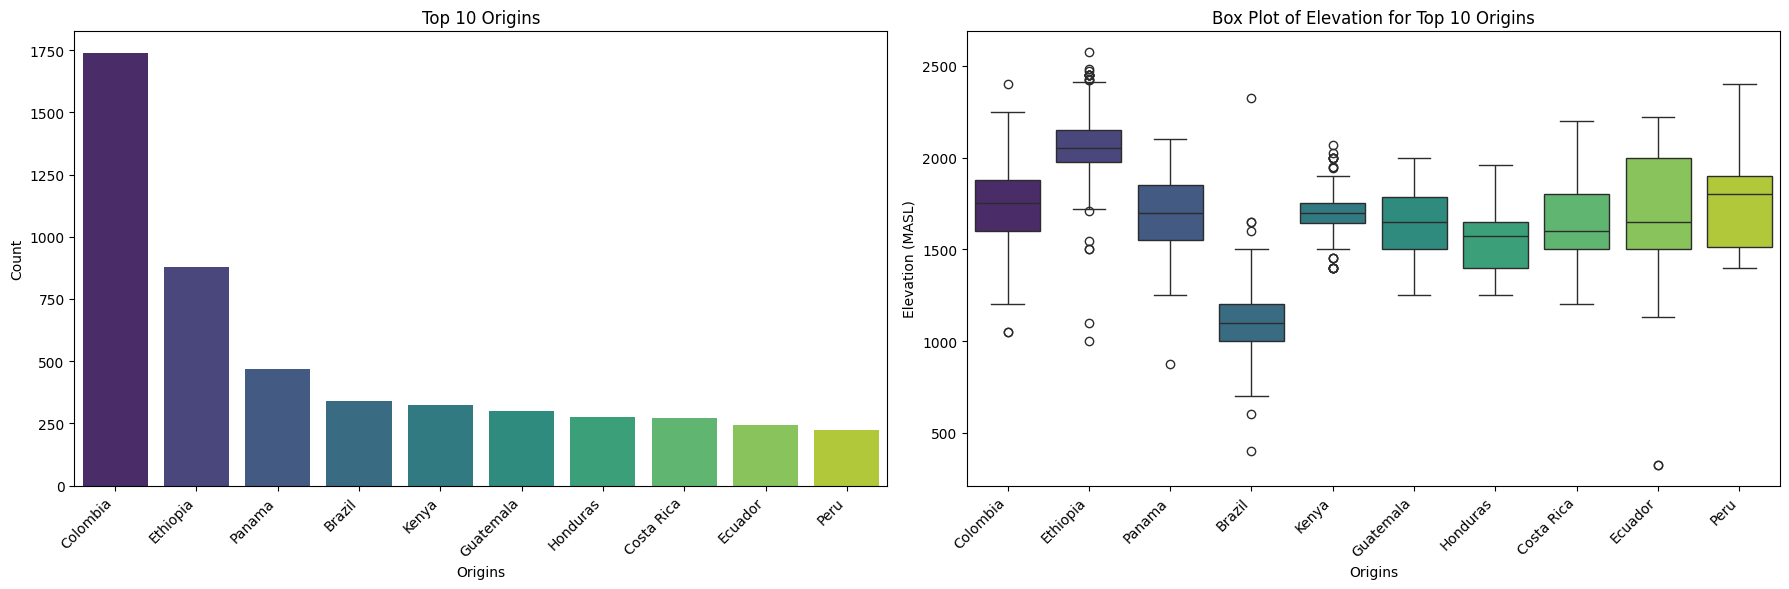

In [18]:
top_10_origins = merged_df['Origins'].value_counts().nlargest(10)
origin_order = top_10_origins.index
top_10_df = merged_df[merged_df['Origins'].isin(origin_order)].sort_values(by='Elevation (MASL)', ascending=False)

plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
sns.barplot(x=origin_order, y=top_10_origins.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Origins')
plt.xlabel('Origins')
plt.ylabel('Count')
plt.tight_layout()


plt.subplot(1, 2, 2)
sns.boxplot(x='Origins', y='Elevation (MASL)', data=top_10_df, palette='viridis', order=origin_order)  # Use the same order
plt.xticks(rotation=45, ha='right')
plt.title('Box Plot of Elevation for Top 10 Origins')
plt.xlabel('Origins')
plt.ylabel('Elevation (MASL)')
plt.tight_layout()

As far as specialty coffee goes, Columbia is the biggest producer. In contrast to commodity coffee where Brazil is the largest.

Ethiopia has the highest elevation by a large margin, although barring Brazil, most specialty coffee is grown in high elevations. Brazil is a clear outlier with coffee grown at much lower elevations. The narrow spread of Kenya indicates there is a narrow elevation range where specialty coffee thrives, although there are a number of outliers. In contrast, Ecuador has a fairly large spread from about 1500 to 2000.

<ipython-input-62-4b3636ade60d>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Process', data=process_df, order=processes.index, palette='viridis')


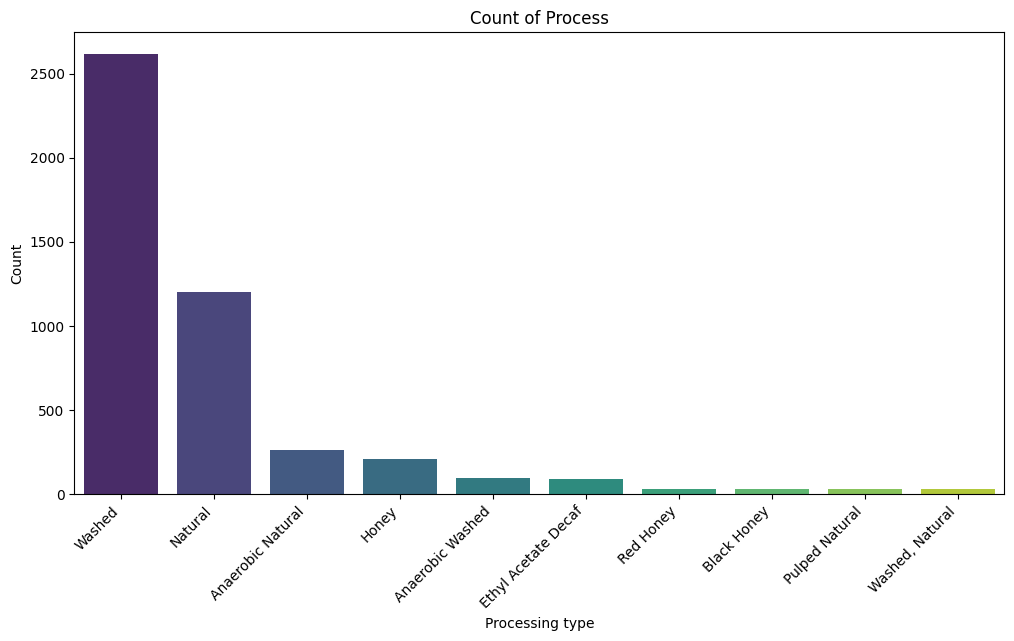

In [62]:
standardised_process = {
    'Fully Washed': 'Washed',
    'Washed Ethyl Acetate Decaf':'Ethyl Acetate Decaf'}

merged_df['Process'] = merged_df['Process'].replace(standardised_process)
processes = merged_df[merged_df['Process']!='-']['Process'].value_counts().nlargest(10)
process_df =  merged_df[merged_df['Process'].isin(processes.index)]


plt.figure(figsize=(12, 6))
sns.countplot(x='Process', data=process_df, order=processes.index, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Count of Process')
plt.xlabel('Processing type')
plt.ylabel('Count')
plt.show()

Overwhelming majority of coffees are washed while ±half are natural. The myriad of other processing options are such a small makeup.

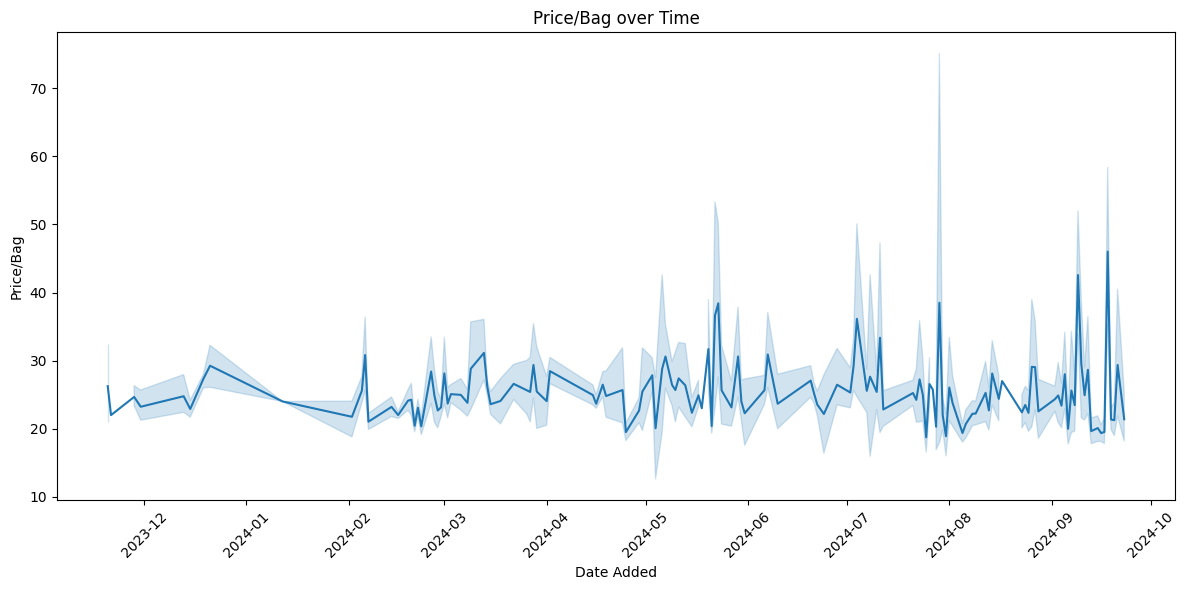

In [24]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date Added', y='Price/Bag',data=merged_df)
plt.title('Price/Bag over Time')
plt.xlabel('Date Added')
plt.ylabel('Price/Bag')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()